# Job Market Data Pipeline

**Steps:**
1. Install & Import Libraries
2. Extract (Load CSV files)
3. Data Quality Checks
4. Transform (Clean Data)
5. Load (Insert to PostgreSQL)
6. SQL Analysis
7. Visualizations

## Step 1: Install & Import Libraries

In [1]:
# Install required libraries (run once)
# !pip install pandas sqlalchemy psycopg2-binary matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Extract (Load CSV Files)

In [3]:
# path to data
file_path = "job_posting_data"

In [4]:
# Load all 6 CSV files into DataFrames
company     = pd.read_csv(file_path + '/company_fixed.csv')
skill       = pd.read_csv(file_path + '/skill_fixed.csv')
job_location = pd.read_csv(file_path + '/job_location_fixed.csv')
job_title   = pd.read_csv(file_path + '/job_title_fixed.csv')
job_posting = pd.read_csv(file_path + '/job_posting_fixed.csv')
job_posting_skills = pd.read_csv(file_path + '/job_posting_skills_fixed.csv')

print('Files loaded successfully!')
print(f'company:             {len(company):,} rows')
print(f'skill:               {len(skill):,} rows')
print(f'job_location:        {len(job_location):,} rows')
print(f'job_title:           {len(job_title):,} rows')
print(f'job_posting:         {len(job_posting):,} rows')
print(f'job_posting_skills:  {len(job_posting_skills):,} rows')

Files loaded successfully!
company:             25,114 rows
skill:               170 rows
job_location:        25,114 rows
job_title:           25,114 rows
job_posting:         25,114 rows
job_posting_skills:  40,308 rows


In [5]:
# Preview job_posting
job_posting.head()

,job_posting_id,job_posting_date,job_posting_type,job_posting_level,years_of_experience,minimum_pay,maximum_pay,pay_rate,num_of_applicants,company_id,job_title_id,location_id
0,2701524240,01/01/2017 00:00,Full-time,Entry level,1,NaN,NaN,NaN,6.0,1,1,1
1,2719108338,01/01/2017 00:00,Full-time,Mid-Senior level,2,NaN,NaN,NaN,1.0,2,2,2
2,2719503370,01/01/2017 00:00,Full-time,Entry level,5,NaN,NaN,NaN,16.0,3,3,3
3,2734877741,01/01/2017 00:00,Full-time,Entry level,2,NaN,NaN,NaN,1.0,4,4,4
4,2752415616,01/01/2017 00:00,Contract,Mid-Senior level,4,NaN,NaN,NaN,NaN,5,5,5


In [6]:
# Check column names and data types
job_posting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25114 entries, 0 to 25113
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_posting_id       25114 non-null  int64  
 1   job_posting_date     25114 non-null  object 
 2   job_posting_type     25114 non-null  object 
 3   job_posting_level    25114 non-null  object 
 4   years_of_experience  25114 non-null  int64  
 5   minimum_pay          1812 non-null   float64
 6   maximum_pay          1812 non-null   float64
 7   pay_rate             1812 non-null   object 
 8   num_of_applicants    17529 non-null  float64
 9   company_id           25114 non-null  int64  
 10  job_title_id         25114 non-null  int64  
 11  location_id          25114 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.3+ MB


## Step 3: Data Quality Checks

In [7]:
# Check 1: Count NULL values in each column
job_posting.isnull().sum()

job_posting_id             0
job_posting_date           0
job_posting_type           0
job_posting_level          0
years_of_experience        0
minimum_pay            23302
maximum_pay            23302
pay_rate               23302
num_of_applicants       7585
company_id                 0
job_title_id               0
location_id                0
dtype: int64

In [8]:
# Check 2: Check for duplicate IDs
dup_company_id = company["company_id"].duplicated().sum()
dup_skill_id = skill["skill_id"].duplicated().sum()
dup_job_posting_id = job_posting["job_posting_id"].duplicated().sum()

In [9]:
dup_company_id

np.int64(0)

In [10]:
dup_skill_id

np.int64(0)

In [11]:
dup_job_posting_id

np.int64(0)

In [12]:
# Check 3: lets finds how many rows where minimum_pay > maximum_pay (salary reversals)
has_salary = job_posting.dropna(subset=['minimum_pay', 'maximum_pay'])
reversed_salary = has_salary[has_salary['minimum_pay'] > has_salary['maximum_pay']]

print(f'Rows with reversed salary: {len(reversed_salary)}')

Rows with reversed salary: 0


In [13]:
reversed_salary[['job_posting_id', 'minimum_pay', 'maximum_pay']].head()

,job_posting_id,minimum_pay,maximum_pay


In [14]:
# Check 4: pay_rate overview
print(job_posting['pay_rate'].value_counts(dropna=False))

pay_rate
NaN    23302
yr      1496
hr       316
Name: count, dtype: int64


In [15]:
# Check 5: years_of_experience range

print(f'Min: {job_posting["years_of_experience"].min()}')
print(f'Max: {job_posting["years_of_experience"].max()}')

# Flag any unrealistic values
bad_exp = job_posting[(job_posting['years_of_experience'] < 0) | 
                       (job_posting['years_of_experience'] > 50)] # (|) sign work as AND operator
print(f'Invalid experience: {len(bad_exp)}')

Min: 0
Max: 25
Invalid experience: 0


In [16]:
# QUALITY SUMMARY — All checks together
print('='*30)
print('     DATA QUALITY REPORT')
print('='*30)

checks = {
    'No duplicate company_id':    company['company_id'].duplicated().sum() == 0,
    'No duplicate job_posting_id':job_posting['job_posting_id'].duplicated().sum() == 0,
    'No null job_posting_id':     job_posting['job_posting_id'].isnull().sum() == 0,
    'No null company_id':         job_posting['company_id'].isnull().sum() == 0,
    'Valid pay_rate':             job_posting['pay_rate'].dropna().isin(['hr','yr']).all(),
    'Valid experience range':     bad_exp.empty,
    'No salary reversals':        len(reversed_salary) == 0
}

for check, passed in checks.items():
    status = 'PASS' if passed else 'FAIL'
    print(f'{status}  {check}')

passed_count = sum(checks.values())
print(f'\nResult: {passed_count}/{len(checks)} checks passed')

     DATA QUALITY REPORT
PASS  No duplicate company_id
PASS  No duplicate job_posting_id
PASS  No null job_posting_id
PASS  No null company_id
PASS  Valid pay_rate
PASS  Valid experience range
PASS  No salary reversals

Result: 7/7 checks passed


## Step 4: Transform (Clean the Data)

In [17]:
# TRANSFORM 1: Fix salary reversals — swap min and max
mask = (
    job_posting['minimum_pay'].notna() &
    job_posting['maximum_pay'].notna() &
    (job_posting['minimum_pay'] > job_posting['maximum_pay'])
)
# Swap minimum and maximum pay for those rows
job_posting.loc[mask, ['minimum_pay', 'maximum_pay']] = job_posting.loc[mask, ['maximum_pay', 'minimum_pay']].values

print(f'fix {mask.sum()} salary reversal rows')

fix 0 salary reversal rows


In [18]:
# TRANSFORM 2: Convert job_posting_date to datetime
job_posting['job_posting_date'] = pd.to_datetime( job_posting['job_posting_date'], format='%m/%d/%Y %H:%M', errors='coerce')

# Extract year and month as separate columns
job_posting['job_year']  = job_posting['job_posting_date'].dt.year
job_posting['job_month'] = job_posting['job_posting_date'].dt.month

print('Dates converted!')
print(job_posting[['job_posting_date', 'job_year', 'job_month']].head())

Dates converted!
  job_posting_date  job_year  job_month
0       2017-01-01    2017.0        1.0
1       2017-01-01    2017.0        1.0
2       2017-01-01    2017.0        1.0
3       2017-01-01    2017.0        1.0
4       2017-01-01    2017.0        1.0


In [19]:
# TRANSFORM 3: Add pay_category column
conditions = [
    job_posting['maximum_pay'] >= 150000,
    job_posting['maximum_pay'] >= 120000,
    job_posting['maximum_pay'] >= 90000,
    job_posting['maximum_pay'] >= 50000
]
labels = ['High Pay', 'Mid Pay', 'Low Pay', 'Lowest Pay']

job_posting['pay_category'] = np.select(conditions, labels, default='No Salary')

print('Pay categories added!')
print(job_posting['pay_category'].value_counts())

Pay categories added!
pay_category
No Salary     23307
High Pay        613
Low Pay         474
Mid Pay         452
Lowest Pay      268
Name: count, dtype: int64


In [20]:
# TRANSFORM 4: Add experience_level column
exp_conditions = [
    job_posting['years_of_experience'] >= 6,
    job_posting['years_of_experience'] >= 3,
    job_posting['years_of_experience'] >= 0
]
exp_labels = ['Senior', 'Mid', 'Junior']

job_posting['experience_level'] = np.select(exp_conditions, exp_labels, default='Not Specified')

print('Experience levels added!')
print(job_posting['experience_level'].value_counts())

Experience levels added!
experience_level
Mid       12884
Senior     7005
Junior     5225
Name: count, dtype: int64


In [21]:
# TRANSFORM 5: Normalize text columns
skill['skill_name']             = skill['skill_name'].str.lower().str.strip()
company['company_name']         = company['company_name'].str.strip()
company['company_industry']     = company['company_industry'].str.strip()

print('Text columns normalized!')

print(f"\n{company['company_industry'].head()}")
print(f"\n{company['company_name'].head()}")
print(f"\n{skill['skill_name'].head()}")

Text columns normalized!

0        Financial Services
1      Consumer Electronics
2         Computer Software
3    Hospital & Health Care
4                  Internet
Name: company_industry, dtype: object

0    Cardinal Financial Company, Limited Partnership
1                                        Brinks Home
2                                             Paycor
3                                              Optum
4                                             Toptal
Name: company_name, dtype: object

0      database
1    javascript
2         agile
3         linux
4        server
Name: skill_name, dtype: object


In [22]:
# Preview cleaned job_posting
job_posting[['job_posting_id', 'job_year', 'pay_category', 
             'experience_level', 'minimum_pay', 'maximum_pay']].head(20)

,job_posting_id,job_year,pay_category,experience_level,minimum_pay,maximum_pay
0,2701524240,2017.0,No Salary,Junior,NaN,NaN
1,2719108338,2017.0,No Salary,Junior,NaN,NaN
2,2719503370,2017.0,No Salary,Mid,NaN,NaN
3,2734877741,2017.0,No Salary,Junior,NaN,NaN
4,2752415616,2017.0,No Salary,Mid,NaN,NaN
5,2697854773,2017.0,No Salary,Senior,NaN,NaN
6,2723260660,2017.0,No Salary,Mid,NaN,NaN
7,2628572485,2017.0,No Salary,Mid,NaN,NaN
8,2748225724,2017.0,No Salary,Senior,NaN,NaN
9,2681258907,2017.0,Lowest Pay,Mid,71000.0,80000.0


## Step 5: Load (Insert to PostgreSQL)

In [24]:
from dotenv import load_dotenv
import os

load_dotenv()

connection_string = f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
engine = create_engine(connection_string)
print('Database connected!')

Database connected!


In [26]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT column_name 
        FROM information_schema.columns 
        WHERE table_name = 'company'
        ORDER BY ordinal_position
    """))
    print("Actual columns in 'company' table:")
    for row in result:
        print(" -", row[0])

Actual columns in 'company' table:


In [28]:
# Load tables (parents before children!) otherwise you will get error. 
# IMPORTANT: Tables must already exist in PostgreSQL!

tables_in_order = [
    ('company',             company),
    ('skill',               skill),
    ('job_location',        job_location),
    ('job_title',           job_title),
    ('job_posting',         job_posting),
    ('job_posting_skills',  job_posting_skills)
]

for table_name, df in tables_in_order:
    df.to_sql(
        name      = table_name,
        con       = engine,
        if_exists = 'append',   # append to existing table
        index     = False,      # don't write DataFrame index
        method    = 'multi',    # bulk insert
        chunksize = 1000        # 1000 rows at a time
    )
    print(f'Loaded {len(df):,} rows into {table_name}')

print('\nAll tables loaded successfully!')

Loaded 25,114 rows into company
Loaded 170 rows into skill
Loaded 25,114 rows into job_location
Loaded 25,114 rows into job_title
Loaded 25,114 rows into job_posting
Loaded 40,308 rows into job_posting_skills

All tables loaded successfully!


In [29]:
# Verify row counts in database
with engine.connect() as conn:
    for table_name, _ in tables_in_order:
        result = conn.execute(text(f'SELECT COUNT(*) FROM {table_name}'))
        count = result.scalar()
        print(f'{table_name}: {count:,} rows in database')

company: 50,228 rows in database
skill: 340 rows in database
job_location: 50,228 rows in database
job_title: 50,228 rows in database
job_posting: 50,228 rows in database
job_posting_skills: 80,616 rows in database


## Step 6: SQL Analysis (Query from Python)

In [31]:
# Helper function to run SQL and return DataFrame
def run_sql(query):
    return pd.read_sql(query, engine)

In [34]:
# QUERY 1: Year-over-Year Growth
yoy_query = """
WITH yearly_jobs AS (
    SELECT
        EXTRACT(YEAR FROM job_posting_date) AS job_year,
        COUNT(*) AS total_jobs
    FROM job_posting
    GROUP BY 1
)
SELECT
    job_year,
    total_jobs,
    LAG(total_jobs) OVER(ORDER BY job_year) AS prev_year,
    total_jobs - LAG(total_jobs) OVER(ORDER BY job_year) AS growth,
    ROUND(
        (total_jobs - LAG(total_jobs) OVER(ORDER BY job_year))
        * 100.0 / LAG(total_jobs) OVER(ORDER BY job_year), 1
    ) AS growth_rate_pct
FROM yearly_jobs
ORDER BY job_year
"""

yoy_df = run_sql(yoy_query)
print('Year-over-Year Growth:')
yoy_df

Year-over-Year Growth:


,job_year,total_jobs,prev_year,growth,growth_rate_pct
0,2017.0,2408,NaN,NaN,NaN
1,2018.0,2938,2408.0,530.0,22.0
2,2019.0,3026,2938.0,88.0,3.0
3,2020.0,5020,3026.0,1994.0,65.9
4,2021.0,6400,5020.0,1380.0,27.5
5,NaN,30436,6400.0,24036.0,375.6


In [35]:
# QUERY 2: Top 10 Most In-Demand Skills
skills_query = """
SELECT
    skill.skill_name,
    COUNT(DISTINCT job_posting.job_posting_id) AS total_jobs,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM job_posting), 1) AS demand_pct
FROM job_posting
JOIN job_posting_skills ON job_posting_skills.job_posting_id = job_posting.job_posting_id
JOIN skill ON skill.skill_id = job_posting_skills.skill_id
GROUP BY skill.skill_name
ORDER BY total_jobs DESC
LIMIT 10
"""

skills_df = run_sql(skills_query)
print('Top 10 Skills:')
skills_df

Top 10 Skills:


,skill_name,total_jobs,demand_pct
0,cloud,2164,34.5
1,sql,2101,33.5
2,python,1997,31.8
3,aws,1820,29.0
4,agile,1471,23.4
5,programming,1340,21.3
6,java,1118,17.8
7,azure,982,15.6
8,database,939,15.0
9,excel,878,14.0


In [38]:
# QUERY 3: Average Salary by Job Level
salary_query = """
SELECT
    job_posting_level,
    ROUND(AVG(minimum_pay)::numeric, 0) AS avg_min_pay,
    ROUND(AVG(maximum_pay)::numeric, 0) AS avg_max_pay,
    COUNT(*) AS total_jobs
FROM job_posting
WHERE maximum_pay IS NOT NULL
  AND minimum_pay IS NOT NULL
GROUP BY 1
ORDER BY avg_max_pay DESC NULLS LAST
"""

salary_df = run_sql(salary_query)
print('Salary by Job Level:')
salary_df

Salary by Job Level:


,job_posting_level,avg_min_pay,avg_max_pay,total_jobs
0,Director,139565.0,184087.0,46
1,Executive,125750.0,147750.0,8
2,Mid-Senior level,112196.0,147448.0,2186
3,Associate,83373.0,122717.0,932
4,Entry level,73633.0,116153.0,430
5,Internship,55818.0,107182.0,22


In [39]:
# QUERY 4: Top Companies by Job Postings
companies_query = """
SELECT
    company.company_name,
    company.company_industry,
    COUNT(*) AS total_jobs
FROM job_posting
LEFT JOIN company ON job_posting.company_id = company.company_id
GROUP BY company.company_name, company.company_industry
ORDER BY total_jobs DESC
LIMIT 10
"""

companies_df = run_sql(companies_query)
print('Top 10 Companies:')
companies_df

Top 10 Companies:


,company_name,company_industry,total_jobs
0,Toptal,Internet,5312
1,Jobot,Staffing & Recruiting,2136
2,Perficient,Information Technology & Services,1024
3,HashiCorp,Computer Software,864
4,Dice,Internet,800
5,Blackbaud,Computer Software,628
6,Affirm,Financial Services,616
7,Netskope,Computer Software,536
8,Trimble Inc.,Information Technology & Services,360
9,Recruiting from Scratch,Staffing & Recruiting,360


## Step 7: Visualizations

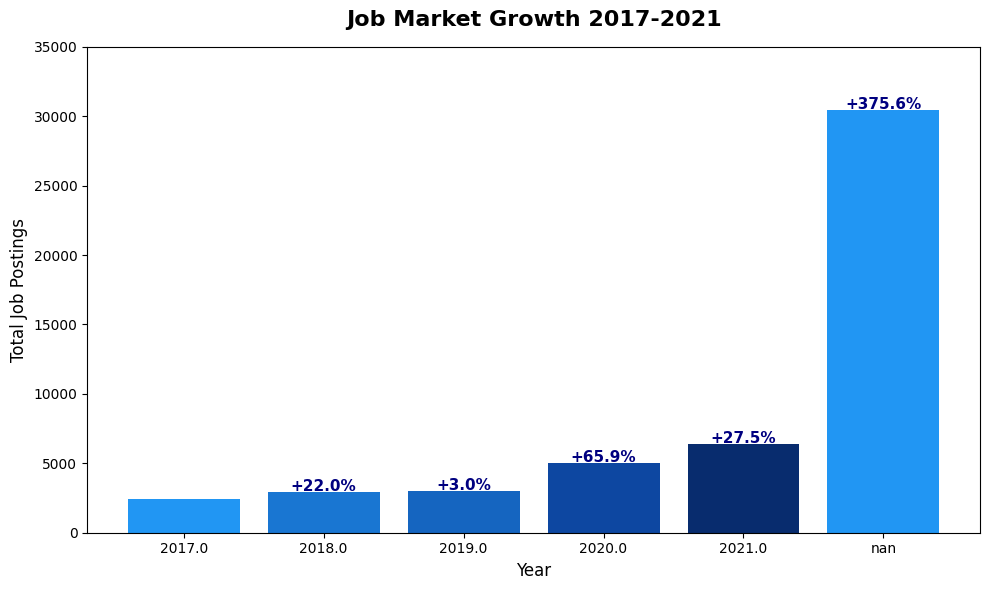

Chart saved as yearly_growth.png


In [40]:
# CHART 1: Job Market Growth (Bar Chart)
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    yoy_df['job_year'].astype(str),
    yoy_df['total_jobs'],
    color=['#2196F3', '#1976D2', '#1565C0', '#0D47A1', '#082C6E']
)

# Add growth rate labels on top of bars
for i, (bar, row) in enumerate(zip(bars, yoy_df.itertuples())):
    if i > 0 and row.growth_rate_pct:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'+{row.growth_rate_pct:.1f}%',
            ha='center', fontweight='bold', color='navy', fontsize=11
        )

ax.set_title('Job Market Growth 2017-2021', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Job Postings', fontsize=12)
ax.set_ylim(0, yoy_df['total_jobs'].max() * 1.15)

plt.tight_layout()
plt.savefig('yearly_growth.png', dpi=150)
plt.show()
print('Chart saved as yearly_growth.png')

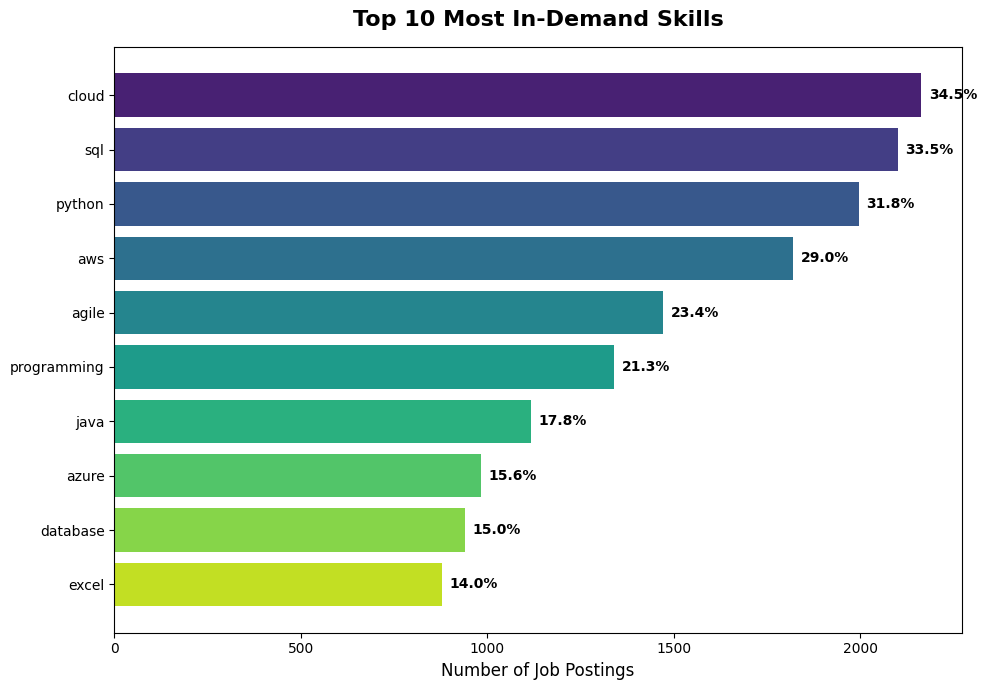

Chart saved as skill_demand.png


In [41]:
# CHART 2: Top 10 Skills (Horizontal Bar Chart)
fig, ax = plt.subplots(figsize=(10, 7))

colors = sns.color_palette('viridis', len(skills_df))
bars = ax.barh(skills_df['skill_name'], skills_df['total_jobs'], color=colors)

# Add percentage labels
for bar, pct in zip(bars, skills_df['demand_pct']):
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}%',
        va='center', fontweight='bold', fontsize=10
    )

ax.set_title('Top 10 Most In-Demand Skills', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Job Postings', fontsize=12)
ax.invert_yaxis()  # highest at top

plt.tight_layout()
plt.savefig('skill_demand.png', dpi=150)
plt.show()
print('Chart saved as skill_demand.png')

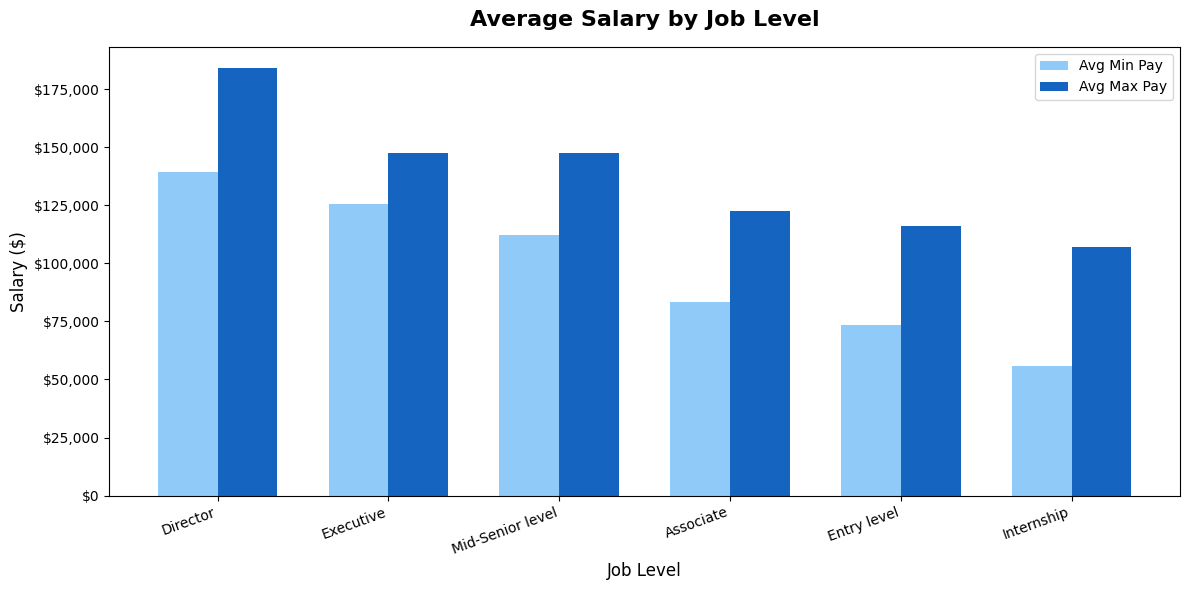

Chart saved as salary_by_level.png


In [42]:
# CHART 3: Salary by Job Level (Bar Chart)
salary_clean = salary_df.dropna(subset=['avg_max_pay'])

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(salary_clean))
width = 0.35

ax.bar([i - width/2 for i in x], salary_clean['avg_min_pay'],
       width, label='Avg Min Pay', color='#90CAF9')
ax.bar([i + width/2 for i in x], salary_clean['avg_max_pay'],
       width, label='Avg Max Pay', color='#1565C0')

ax.set_title('Average Salary by Job Level', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Job Level', fontsize=12)
ax.set_ylabel('Salary ($)', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(salary_clean['job_posting_level'], rotation=20, ha='right')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.tight_layout()
plt.savefig('salary_by_level.png', dpi=150)
plt.show()
print('Chart saved as salary_by_level.png')

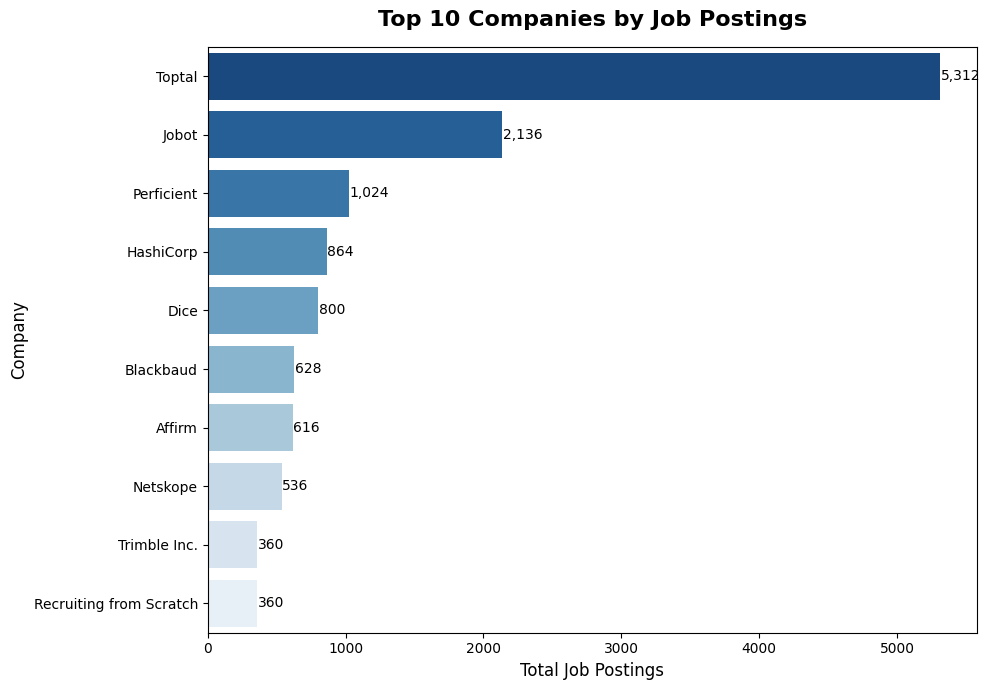

Chart saved as top_companies.png


In [44]:
# CHART 4: Top 10 Companies (Horizontal Bar)
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=companies_df,
    y='company_name',
    x='total_jobs',
    hue='company_name',      # ← add this
    palette='Blues_r',
    legend=False,            # ← add this
    ax=ax
)

# Add value labels
for bar in ax.patches:
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width()):,}',
        va='center', fontsize=10
    )

ax.set_title('Top 10 Companies by Job Postings', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Job Postings', fontsize=12)
ax.set_ylabel('Company', fontsize=12)
plt.tight_layout()
plt.savefig('top_companies.png', dpi=150)
plt.show()
print('Chart saved as top_companies.png')

In [45]:
with open('.gitignore', 'a') as f:
    f.write('\n.env\n')

print('.gitignore updated!')

.gitignore updated!


### Output Files:
- `yearly_growth.png`
- `skill_demand.png`
- `salary_by_level.png`
- `top_companies.png`